## 1. Setup: Load Overlay and Libraries

In [37]:
from pynq import Overlay, allocate, MMIO
import numpy as np
import time
import matplotlib.pyplot as plt
from IPython.display import Image, display

#===============================================================================
# @brief AXI-Lite Control Register Map for sortLattice_AXI Kernel
#
# @details Defines all register offsets for:
#   - Control signals (CTRL, AP_START, AP_DONE, AP_IDLE, AP_READY)
#   - 64-bit address pointers (STATE, TARGET, MOVELIST)
#   - Scalar parameters (ROWS, COLS, computation zone bounds)
#   - Output status (MOVECOUNT)
#===============================================================================

# Control/status registers
CTRL = 0x00                    # Control register (AP_START, AP_DONE, etc.)
AP_START, AP_DONE, AP_IDLE, AP_READY = 1 << 0, 1 << 1, 1 << 2, 1 << 3

# 64-bit pointer registers (AXI Master m_axi_state, m_axi_target, m_axi_movelist)
ADDR_STATE_LO    = 0x10        # State buffer physical address (low 32-bit)
ADDR_STATE_HI    = 0x14        # State buffer physical address (high 32-bit)
ADDR_TARGET_LO   = 0x1C        # Target geometry buffer address (low 32-bit)
ADDR_TARGET_HI   = 0x20        # Target geometry buffer address (high 32-bit)
ADDR_MOVELIST_LO = 0x28        # Move list buffer address (low 32-bit)
ADDR_MOVELIST_HI = 0x2C        # Move list buffer address (high 32-bit)

# Scalar parameters (AXI Lite)
ADDR_ROWS   = 0x34             # Full lattice height (rows)
ADDR_COLS   = 0x3C             # Full lattice width (columns)
ADDR_RSTART = 0x44             # Computation zone start row
ADDR_REND   = 0x4C             # Computation zone end row (exclusive)
ADDR_CSTART = 0x54             # Computation zone start column
ADDR_CEND   = 0x5C             # Computation zone end column (exclusive)

# Output registers
ADDR_MOVECOUNT = 0x64          # Number of parallel moves generated

#===============================================================================
# @brief Read and display FPGA kernel control status
#
# @param[in] mmio MMIO object for register access
# @param[in] label Optional label for debug output
#
# @details Displays: START bit, DONE bit, IDLE bit, READY bit
#===============================================================================
def dump_ctrl(mmio, label=""):
    """Display control register status."""
    v = mmio.read(CTRL)
    if label: print(f"[{label}]")
    print(f"CTRL=0x{v:08X} | START={(v&AP_START)>0} DONE={(v&AP_DONE)>0} IDLE={(v&AP_IDLE)>0} READY={(v&AP_READY)>0}")

#===============================================================================
# @brief Write 64-bit physical address to AXI-Lite register pair
#
# @param[in] mmio MMIO object for register access
# @param[in] lo Low 32-bit register offset
# @param[in] hi High 32-bit register offset  
# @param[in] addr 64-bit physical address to write
#
# @details Splits 64-bit address into two 32-bit writes
#===============================================================================
def write_addr64(mmio, lo, hi, addr):
    """Write 64-bit physical address split into two 32-bit registers."""
    mmio.write(lo, int(addr) & 0xFFFFFFFF)
    mmio.write(hi, (int(addr) >> 32) & 0xFFFFFFFF)

#===============================================================================
# @brief Load FPGA bitstream overlay
#
# @details Loads design_2_wrapper.bit and initializes MMIO interface
#          to sortLattice_AXI_0 kernel
#===============================================================================
print("Loading overlay...")
ol = Overlay("design_2_wrapper.bit")
ol.download()
print("✓ Overlay loaded")

ip_desc = ol.ip_dict["sortLattice_AXI_0"]
mmio = MMIO(ip_desc["phys_addr"], ip_desc["addr_range"])
dump_ctrl(mmio, "Initial")

Loading overlay...
✓ Overlay loaded
[Initial]
CTRL=0x00000004 | START=False DONE=False IDLE=True READY=False


## 2. Configure: Lattice and Target

In [88]:
#===============================================================================
# @brief Configure lattice dimensions and computation zone
#
# @details 
#   MAX LATTICE SIZE: ROWS × COLS ≤ 25,000 (current FPGA bitstream limit)
#     - Constrained by ARRAY2D_MAX_SIZE compile-time constant in sortLatticeByRow.hpp
#     - Valid configurations: 80×250 (20k), 100×250 (25k), 158×158 (24.9k)
#     - EXCEEDS LIMIT: 150×200 (30k) ✗, 200×200 (40k) ✗
#   
#   TO INCREASE LIMIT:
#     1. Edit include/sortLatticeByRow.hpp: #define ARRAY2D_MAX_SIZE 
#     2. Rebuild HLS kernel
#     3. Regenerate bitstream in Vitis and Vivado (synthesis + implementation)
#     4. Trade-off: Higher limit = more BRAM usage (check utilization report)
#   
#   COMPUTATION ZONE:
#     - Defines target area where atoms are sorted into pattern
#     - Must fit within full lattice: FILLED_ROWS ≤ ROWS, FILLED_COLS ≤ COLS
#     - Minimum: 4×4 (algorithm needs channel spacing)
#     - Typically centered: R0 = (ROWS - FILLED_ROWS) / 2, etc.
#     - Space outside zone used for "parking" atoms during sorting
#
#   TARGET GEOMETRY:
#     - Binary mask defining desired occupancy pattern in computation zone
#     - Size matches computation zone dimensions (FILLED_ROWS × FILLED_COLS)
#     - Can be arbitrary pattern: striped, grid, hexagonal, random, etc.
#     - Algorithm sorts atoms to match this pattern (if possible)
#
# @example
#   # Current working config: 80×250 lattice, 80×90 computation zone
#   ROWS, COLS = 80, 250
#   FILLED_ROWS, FILLED_COLS = 80, 90
#   # Striped target pattern: alternating occupied/empty rows
#
# @see sortLatticeByRow.hpp for ARRAY2D_MAX_SIZE definition 
#===============================================================================

ROWS, COLS = 80, 250              # Full lattice dimensions (≤25k cells for current bitstream)
FILLED_ROWS, FILLED_COLS = 80, 90 # Computation zone dimensions

# Auto-compute centered position
R0 = (ROWS - FILLED_ROWS) // 2    # Comp zone start row
C0 = (COLS - FILLED_COLS) // 2    # Comp zone start column
R1 = R0 + FILLED_ROWS             # Comp zone end row (exclusive)
C1 = C0 + FILLED_COLS             # Comp zone end column (exclusive)

print(f"Lattice: {ROWS}×{COLS}")
print(f"Comp zone: [{R0},{R1})×[{C0},{C1})")

Lattice: 80×250
Comp zone: [0,80)×[80,170)


## 3. Allocate: Memory Buffers

In [89]:
#===============================================================================
# @brief Allocate DMA-accessible memory buffers for kernel I/O
#
# @details Allocates three 64-bit aligned contiguous buffers:
#   - state_buf: Current lattice state (ROWS × COLS boolean array)
#   - target_buf: Target occupancy pattern (FILLED_ROWS × FILLED_COLS boolean)
#   - move_raw: Parallel move list output from kernel (binary format)
#
# @note Requires PYNQ overlay with m_axi DMA ports enabled
#===============================================================================

MOVE_LIST_BYTES = 2_789_376       # Max move buffer size (512 moves × 5448 bytes)

state_buf  = allocate(shape=(ROWS * COLS,), dtype=np.uint8)
target_buf = allocate(shape=(FILLED_ROWS * FILLED_COLS,), dtype=np.uint8)
move_raw   = allocate(shape=(MOVE_LIST_BYTES,), dtype=np.uint8)

state  = state_buf.reshape((ROWS, COLS))
target = target_buf.reshape((FILLED_ROWS, FILLED_COLS))

print(f"state_buf  @ {hex(state_buf.physical_address)} ({state_buf.nbytes} bytes)")
print(f"target_buf @ {hex(target_buf.physical_address)} ({target_buf.nbytes} bytes)")
print(f"move_raw   @ {hex(move_raw.physical_address)} ({move_raw.nbytes} bytes)")

state_buf  @ 0x77ce0000 (20000 bytes)
target_buf @ 0x77cce000 (7200 bytes)
move_raw   @ 0x79e00000 (2789376 bytes)


## 4. Initialize: Random Lattice and Target

In [90]:
#===============================================================================
# @brief Initialize random lattice state and target geometry pattern
#
# @details
#   1. Fill state buffer with random occupancy (Bernoulli ~20%)
#   2. Save initial state for later verification
#   3. Create target pattern (striped configuration)
#   4. Clear move buffer for kernel output
#   5. Flush all buffers to physical memory via DMA coherency
#
# @note Random seed=42 for reproducibility
# @see save initial_state before running kernel (needed for move verification)
#===============================================================================

rng = np.random.default_rng(42)

# Random 20% occupancy
state[:] = (rng.random((ROWS, COLS)) < 0.20).astype(np.uint8)
initial_state = state.copy()
initial_atoms = np.sum(initial_state)
print(f"✓ Initial state: {initial_atoms} atoms")

# Target pattern (striped)
target[:] = 0
for r in range(FILLED_ROWS):
    if r % 4 in (2, 3):
        for j in range(FILLED_COLS // 15):
            for c in range(15*j + 2, 15*j + 13, 2):
                if c < FILLED_COLS:
                    target[r, c] = 1

move_raw[:] = 0
state_buf.flush()
target_buf.flush()
move_raw.flush()
print("✓ Buffers initialized")

✓ Initial state: 4010 atoms
✓ Buffers initialized


## 5. Execute: Run FPGA Kernel

In [91]:
#===============================================================================
# @brief Execute FPGA kernel synchronously
#
# @details
#   1. Write all buffer addresses to AXI-Lite registers (64-bit pointers)
#   2. Write scalar parameters (lattice size, comp zone bounds)
#   3. Poll AP_IDLE until kernel is ready
#   4. Pulse AP_START to trigger kernel execution
#   5. Poll AP_DONE with 10-second timeout
#   6. Read moveCount register for result validation
#
# @return kernel_time_ms Execution time in milliseconds
# @return moveCount Number of parallel moves generated
#
# @note Blocks until kernel completion or timeout
# @throw RuntimeError if kernel timeout exceeds 10 seconds
#===============================================================================

# Program buffer physical addresses
write_addr64(mmio, ADDR_STATE_LO,    ADDR_STATE_HI,    state_buf.physical_address)
write_addr64(mmio, ADDR_TARGET_LO,   ADDR_TARGET_HI,   target_buf.physical_address)
write_addr64(mmio, ADDR_MOVELIST_LO, ADDR_MOVELIST_HI, move_raw.physical_address)

# Program scalar parameters
mmio.write(ADDR_ROWS,   ROWS)
mmio.write(ADDR_COLS,   COLS)
mmio.write(ADDR_RSTART, R0)
mmio.write(ADDR_REND,   R1)
mmio.write(ADDR_CSTART, C0)
mmio.write(ADDR_CEND,   C1)

# Wait for idle
while not (mmio.read(CTRL) & AP_IDLE):
    pass

t0 = time.perf_counter()
mmio.write(CTRL, AP_START)
mmio.write(CTRL, 0)

# Wait for done (10 sec timeout)
while True:
    if mmio.read(CTRL) & AP_DONE:
        break
    if time.perf_counter() - t0 > 10.0:
        raise RuntimeError("Kernel timeout")
    time.sleep(0.001)

kernel_time_ms = (time.perf_counter() - t0) * 1e3
moveCount = mmio.read(ADDR_MOVECOUNT)

print(f"✓ Kernel runtime: {kernel_time_ms:.1f} ms")
print(f"✓ Move count: {moveCount}")

✓ Kernel runtime: 42.2 ms
✓ Move count: 350


In [92]:
#===============================================================================
# @brief Render and save lattice state as PNG dot plot
#
# @param[in] state 2D numpy array of lattice occupancy (bool/uint8)
# @param[in] R0 Computation zone start row
# @param[in] R1 Computation zone end row
# @param[in] C0 Computation zone start column
# @param[in] C1 Computation zone end column
# @param[in] filename Output PNG filename
#
# @details
#   - Creates high-DPI (200 DPI) scatter plot with dots at occupied sites
#   - Adds vertical grid lines at computation zone boundaries (C0, C1)
#   - Sets aspect ratio to square (1:1 pixel mapping)
#   - Renders at full lattice resolution (e.g., 80×250)
#
# @note Y-axis is flipped for standard visualization (top = row 0)
#===============================================================================

def save_lattice_png(state, R0, R1, C0, C1, filename):
    """Save lattice as dot plot PNG with computation zone overlay."""
    rows, cols = state.shape
    ys, xs = np.where(state != 0)
    ys = rows - 1 - ys  # flip Y

    fig_w = 12
    fig_h = fig_w * rows / cols

    plt.figure(figsize=(fig_w, fig_h), dpi=200)
    plt.scatter(xs, ys, s=6, marker=".", linewidths=0)
    plt.axvline(C0 - 0.5, linewidth=1, alpha=0.5)
    plt.axvline(C1 - 0.5, linewidth=1, alpha=0.5)
    plt.xlim(-0.5, cols - 0.5)
    plt.ylim(-0.5, rows - 0.5)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.axis("off")
    plt.savefig(filename, bbox_inches="tight", pad_inches=0, dpi=200)
    plt.close()

state_buf.invalidate()

# Save initial and FPGA output
save_lattice_png(initial_state, R0, R1, C0, C1, "lattice_initial.png")
save_lattice_png(state, R0, R1, C0, C1, "lattice_sorted.png")

print("✓ Saved lattice_initial.png")
print("✓ Saved lattice_sorted.png")


✓ Saved lattice_initial.png
✓ Saved lattice_sorted.png


## 6. Decode: Parse Move List from FPGA Memory

In [93]:
import struct

#===============================================================================
# @brief Decode and display parallel moves from FPGA binary buffer
#
# @details 
#   Parses ParallelMove structures and extracts all step selections.
#   Auto-detects size_t width (8-byte vs 4-byte) to match FPGA layout.
#   Row/col selections define a GRID via Cartesian product: all (r_i, c_j).
#   Rows/cols are expected to be non-negative integer indices.
#===============================================================================

MAX_MOVE_STEPS = 20
MAX_SELECTION = 16

# Compute layout parameters for a given size_t width
# Step: 16 doubles (cols) + 16 doubles (rows) + 2 size_t counts
# Move: MAX_MOVE_STEPS steps + 1 size_t stepsCount, aligned to 8 bytes

def compute_layout(size_t_bytes):
    step_size = 256 + 2 * size_t_bytes
    move_bytes = MAX_MOVE_STEPS * step_size + size_t_bytes
    move_stride = (move_bytes + 7) // 8 * 8  # align to 8
    return step_size, move_stride


def decode_parallel_move_full(buf, size_t_bytes, step_size):
    """Decode one ParallelMove from buffer using provided layout."""
    fmt_sz = "<Q" if size_t_bytes == 8 else "<I"

    stepsCount = struct.unpack_from(fmt_sz, buf, MAX_MOVE_STEPS * step_size)[0]
    if stepsCount == 0 or stepsCount > MAX_MOVE_STEPS:
        return None

    steps_data = []
    for step_idx in range(stepsCount):
        step_off = step_idx * step_size
        col_count = struct.unpack_from(fmt_sz, buf, step_off + 256)[0]
        row_count = struct.unpack_from(fmt_sz, buf, step_off + 256 + size_t_bytes)[0]

        if row_count > MAX_SELECTION or col_count > MAX_SELECTION:
            return None

        cols = list(struct.unpack_from(f"<{col_count}d", buf, step_off + 0)) if col_count else []
        rows = list(struct.unpack_from(f"<{row_count}d", buf, step_off + 128)) if row_count else []

        steps_data.append({
            'rowSelection': rows,
            'colSelection': cols
        })

    return steps_data

# Decode all moves from buffer with auto-detected size_t width
move_raw.invalidate()

# Try 8-byte, then 4-byte size_t to match FPGA build
layout_choice = None
for sz in (8, 4):
    step_size_candidate, move_stride_candidate = compute_layout(sz)
    if move_stride_candidate > move_raw.size:
        continue
    first_buf = bytes(move_raw[:move_stride_candidate])
    probe = decode_parallel_move_full(first_buf, sz, step_size_candidate)
    if probe is not None:
        layout_choice = (sz, step_size_candidate, move_stride_candidate)
        break

# Fallback to 8-byte if detection fails
if layout_choice is None:
    sz, step_size_candidate, move_stride_candidate = 8, *compute_layout(8)
else:
    sz, step_size_candidate, move_stride_candidate = layout_choice

size_t_bytes = sz
STEP_SIZE = step_size_candidate
PARALLEL_MOVE_SIZE = move_stride_candidate
fmt_sz = "<Q" if size_t_bytes == 8 else "<I"

max_moves_in_buffer = move_raw.size // PARALLEL_MOVE_SIZE
n = min(moveCount, max_moves_in_buffer)

print(f"Detected size_t = {size_t_bytes} bytes, step_size = {STEP_SIZE}, move_stride = {PARALLEL_MOVE_SIZE}")
print(f"Decoding {n} moves (moveCount register = {moveCount})\n")

all_moves = []
for i in range(n):
    base = i * PARALLEL_MOVE_SIZE
    buf = bytes(move_raw[base:base + PARALLEL_MOVE_SIZE])
    steps_data = decode_parallel_move_full(buf, size_t_bytes, STEP_SIZE)
    
    if steps_data is None:
        break
    
    all_moves.append(steps_data)

# Stats on steps per move
steps_per_move = [len(m) for m in all_moves]
if steps_per_move:
    print(f"Steps per move: min={min(steps_per_move)}, max={max(steps_per_move)}, avg={sum(steps_per_move)/len(steps_per_move):.2f}")
    for k in sorted(set(steps_per_move)):
        cnt = sum(1 for v in steps_per_move if v == k)
        print(f"  {k} steps: {cnt} moves")

# Print move list summary
print("\n" + "="*70)
print("MOVE LIST SUMMARY")
print("="*70)
print(f"Decoded {len(all_moves)} parallel moves\n")

for move in all_moves:
    num_rows = len(move[0]['rowSelection'])
    num_cols = len(move[0]['colSelection'])
    num_steps = len(move) - 1
    print(f"Move shifts {num_rows} rows and {num_cols} columns for {num_steps} steps")


Detected size_t = 8 bytes, step_size = 272, move_stride = 5448
Decoding 350 moves (moveCount register = 350)

Steps per move: min=2, max=4, avg=3.57
  2 steps: 12 moves
  3 steps: 125 moves
  4 steps: 213 moves

MOVE LIST SUMMARY
Decoded 350 parallel moves

Move shifts 1 rows and 16 columns for 1 steps
Move shifts 1 rows and 16 columns for 1 steps
Move shifts 1 rows and 16 columns for 1 steps
Move shifts 1 rows and 7 columns for 1 steps
Move shifts 1 rows and 16 columns for 1 steps
Move shifts 1 rows and 16 columns for 1 steps
Move shifts 1 rows and 16 columns for 1 steps
Move shifts 1 rows and 9 columns for 1 steps
Move shifts 1 rows and 16 columns for 1 steps
Move shifts 1 rows and 16 columns for 1 steps
Move shifts 1 rows and 16 columns for 1 steps
Move shifts 1 rows and 3 columns for 1 steps
Move shifts 1 rows and 16 columns for 2 steps
Move shifts 1 rows and 16 columns for 2 steps
Move shifts 1 rows and 16 columns for 2 steps
Move shifts 1 rows and 7 columns for 2 steps
Move shift

In [94]:
#===============================================================================
# @brief Build sorted lattice by applying decoded moves
##
## @details
##   Uses only the first and last steps of each parallel move, keeping the index
##   mapping (ri, ci) between rowSelection and colSelection. Atoms present at
##   step[0] are cleared, then placed at step[-1] using the same indices.
#===============================================================================

print("\n" + "="*70)
print("BUILD SORTED LATTICE FROM MOVES")
print("="*70)

comp_zone = (R0, R1, C0, C1)

def build_sorted_lattice_from_moves(original_state, parallel_moves, comp_zone):
    """Apply parallel moves by mapping atoms from first to last step."""
    sorted_lattice = original_state.copy()
    row_start, row_end, col_start, col_end = comp_zone  # kept for compatibility
    rows_limit, cols_limit = sorted_lattice.shape

    for move_idx, move in enumerate(parallel_moves):
        if not move:
            continue

        first_step = move[0]
        last_step = move[-1]

        rows0 = first_step["rowSelection"]
        cols0 = first_step["colSelection"]
        rowsN = last_step["rowSelection"]
        colsN = last_step["colSelection"]

        # Use min lengths to avoid index errors if counts differ
        max_rows = min(len(rows0), len(rowsN))
        max_cols = min(len(cols0), len(colsN))

        moving_indices = []

        # Gather atoms present in sorted_lattice at step[0] positions
        for ri in range(max_rows):
            r0_int = int(rows0[ri] + 0.5) if rows0[ri] >= 0 else -1
            if r0_int < 0 or r0_int >= rows_limit:
                continue
            for ci in range(max_cols):
                c0_int = int(cols0[ci] + 0.5) if cols0[ci] >= 0 else -1
                if c0_int < 0 or c0_int >= cols_limit:
                    continue
                if sorted_lattice[r0_int, c0_int]:
                    moving_indices.append((ri, ci, r0_int, c0_int))
                    sorted_lattice[r0_int, c0_int] = False

        # Place atoms at step[-1] positions using same (ri, ci) mapping
        for ri, ci, _, _ in moving_indices:
            if ri >= len(rowsN) or ci >= len(colsN):
                continue
            rN_int = int(rowsN[ri] + 0.5) if rowsN[ri] >= 0 else -1
            cN_int = int(colsN[ci] + 0.5) if colsN[ci] >= 0 else -1
            if 0 <= rN_int < rows_limit and 0 <= cN_int < cols_limit:
                sorted_lattice[rN_int, cN_int] = True

    return sorted_lattice

sorted_state = build_sorted_lattice_from_moves(initial_state, all_moves, comp_zone)
atoms_before = np.sum(initial_state)
atoms_after = np.sum(sorted_state)

print(f"\n✓ Sorted lattice built")
print(f"Atoms preserved: {atoms_before} → {atoms_after} ({100*atoms_after/atoms_before if atoms_before > 0 else 0:.1f}%)")



BUILD SORTED LATTICE FROM MOVES

✓ Sorted lattice built
Atoms preserved: 4010 → 2453 (61.2%)



VISUALIZE & VALIDATE RESULTS

✓ Saved lattice_sorted_from_moves.png
✓ Saved lattice_sorted_fpga.png

- Initial (4010 atoms):



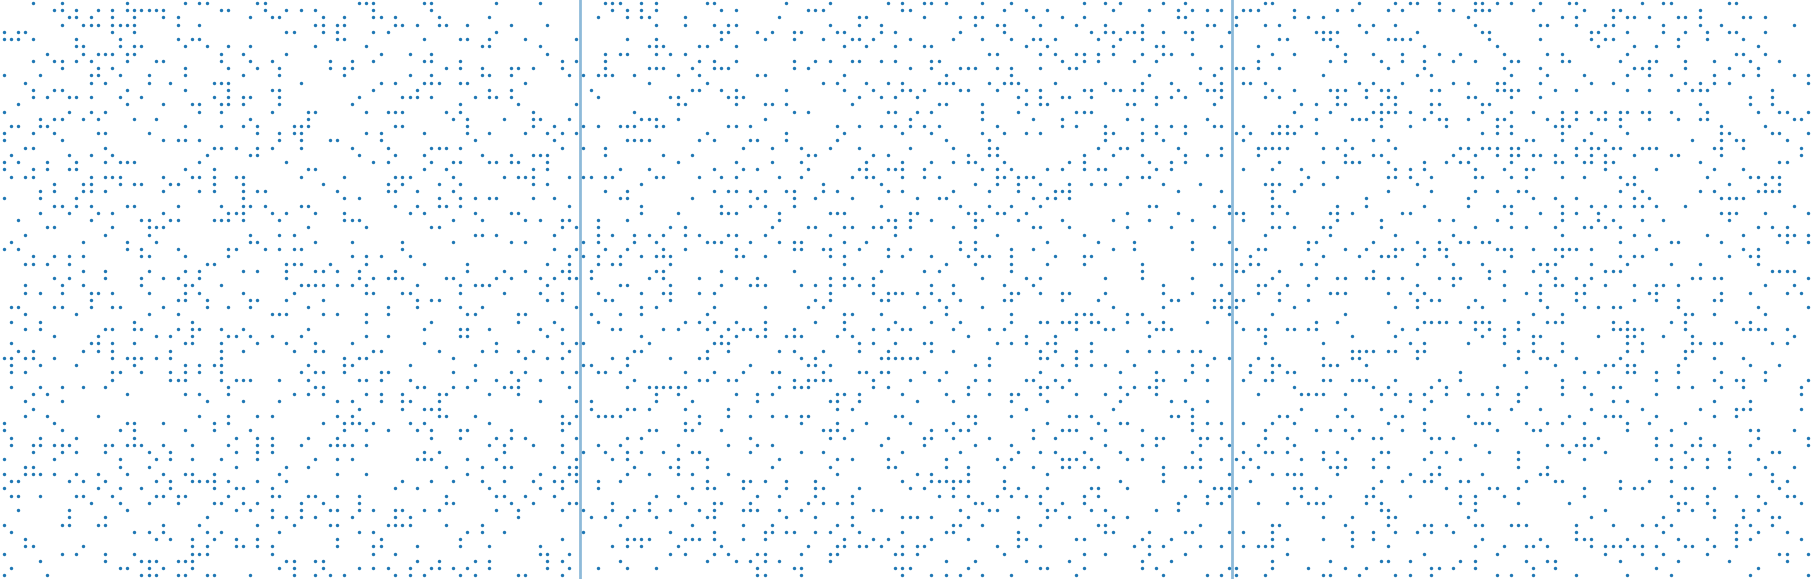


- Reconstructed from Moves (2453 atoms):



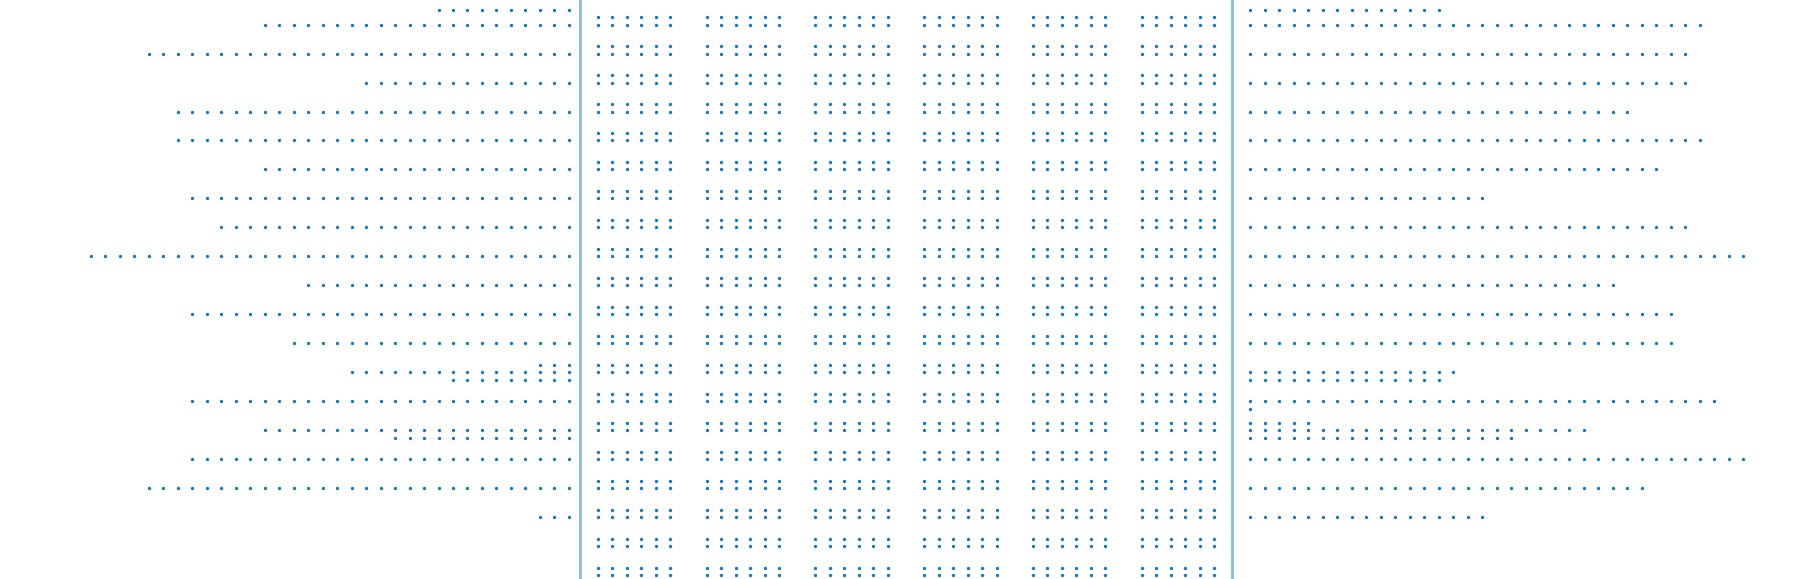


- FPGA Output (2453 atoms):



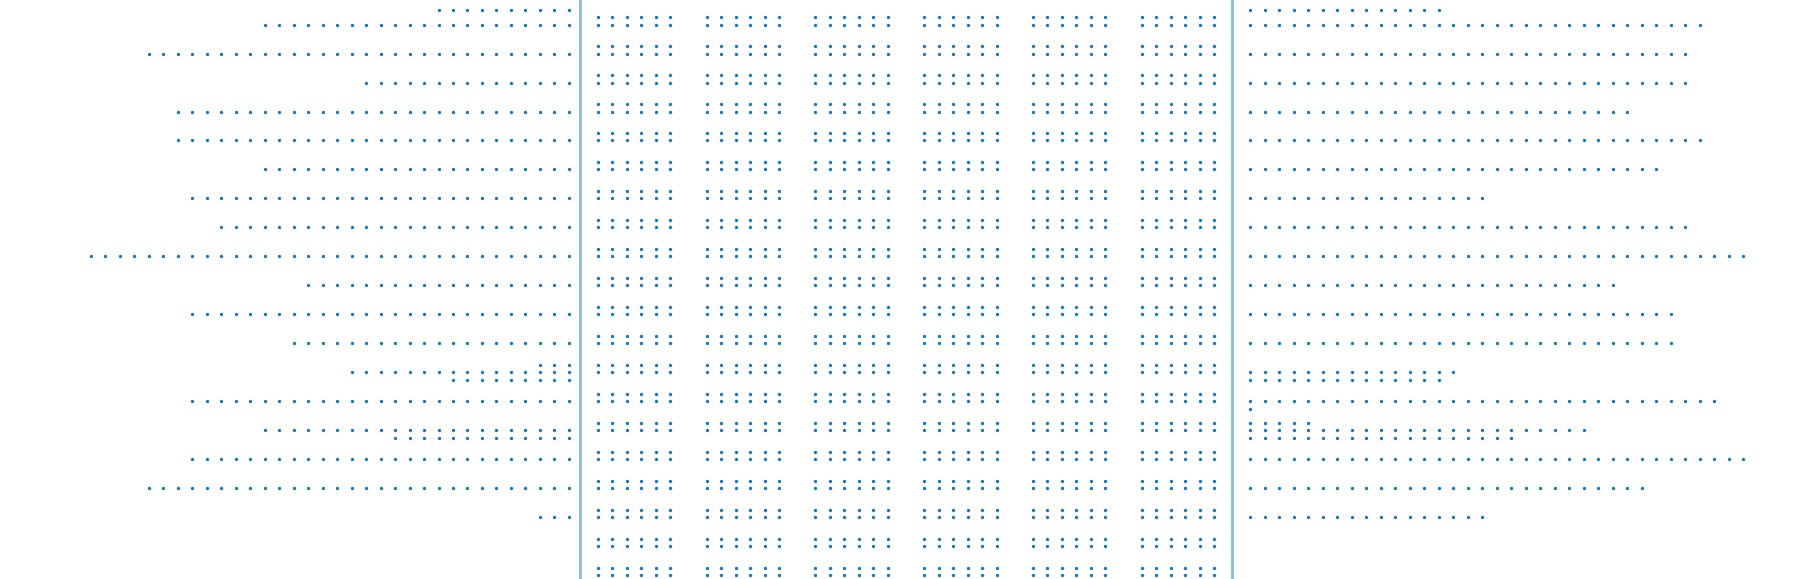


VALIDATION: Moves-Generated vs FPGA Output
Matching cells: 20000/20000 (100.0%)
✅ Perfect match - moves correctly reproduce FPGA result!


In [96]:
#===============================================================================
# @brief Visualize sorted lattices and validate
#
# @details
#   1. Refresh FPGA output from memory
#   2. Save PNGs of reconstructed (from moves) and FPGA output
#   3. Display 3-way comparison: Initial → Reconstructed → FPGA
#   4. Validate match percentage
#===============================================================================

print("\n" + "="*70)
print("VISUALIZE & VALIDATE RESULTS")
print("="*70 + "\n")

# Read back FPGA output
state_buf.invalidate()

# Save images
save_lattice_png(sorted_state, R0, R1, C0, C1, "lattice_sorted_from_moves.png")
save_lattice_png(state, R0, R1, C0, C1, "lattice_sorted_fpga.png")
print("✓ Saved lattice_sorted_from_moves.png")
print("✓ Saved lattice_sorted_fpga.png\n")

# Display 3-way comparison
print(f"- Initial ({np.sum(initial_state)} atoms):\n")
display(Image(filename="lattice_initial.png"))

print(f"\n- Reconstructed from Moves ({atoms_after} atoms):\n")
display(Image(filename="lattice_sorted_from_moves.png"))

print(f"\n- FPGA Output ({np.sum(state)} atoms):\n")
display(Image(filename="lattice_sorted_fpga.png"))

# Validation
match_count = np.sum(sorted_state == state)
total = sorted_state.size
match_pct = 100 * match_count / total

print("\n" + "="*70)
print("VALIDATION: Moves-Generated vs FPGA Output")
print("="*70)
print(f"Matching cells: {match_count}/{total} ({match_pct:.1f}%)")
if match_pct == 100:
    print("✅ Perfect match - The move list produced by the kernel is sufficient to realize the same target configuration when applied by the sorting algorithm")
else:
    print(f"⚠️  {total - match_count} cells differ")
print("="*70)



VISUALIZE & VALIDATE RESULTS

✓ Saved lattice_sorted_from_moves.png
✓ Saved lattice_sorted_fpga.png

- Initial (4010 atoms):



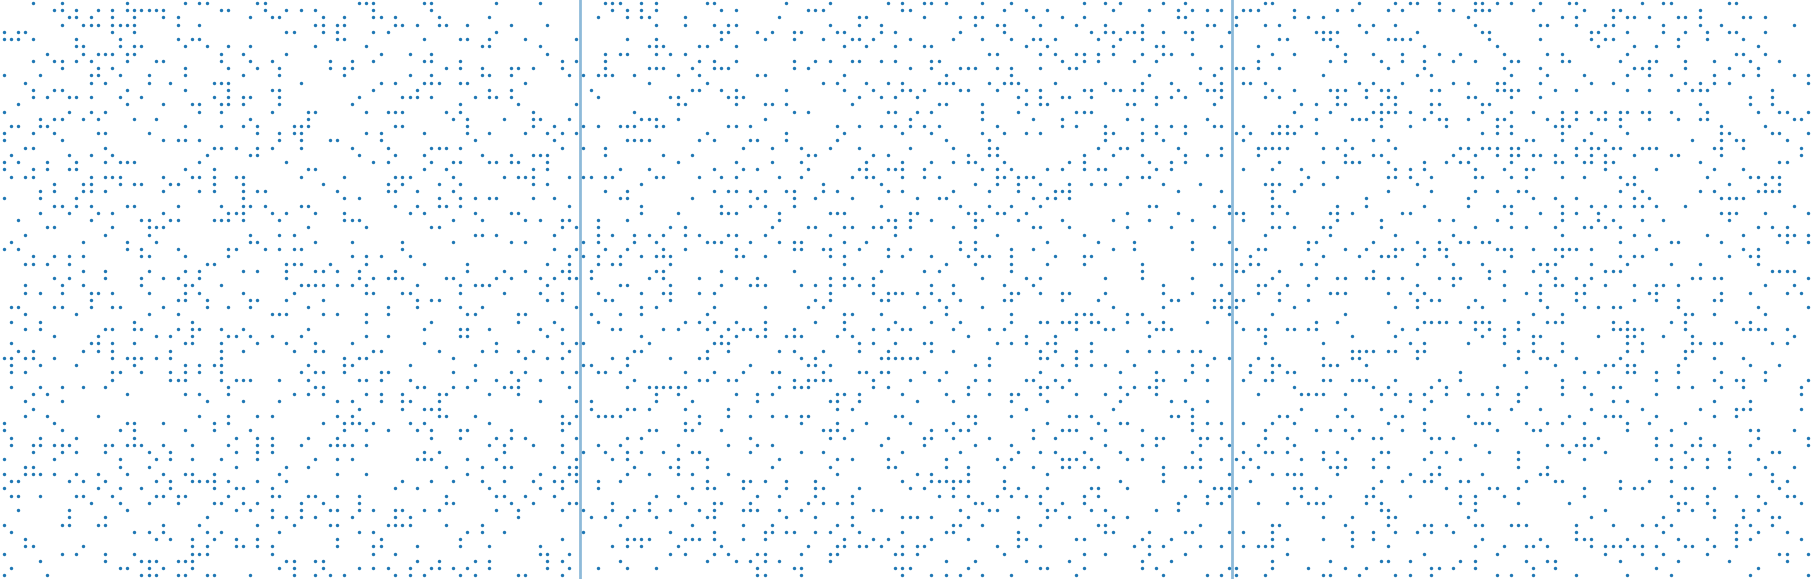


- Reconstructed from Moves (2453 atoms):



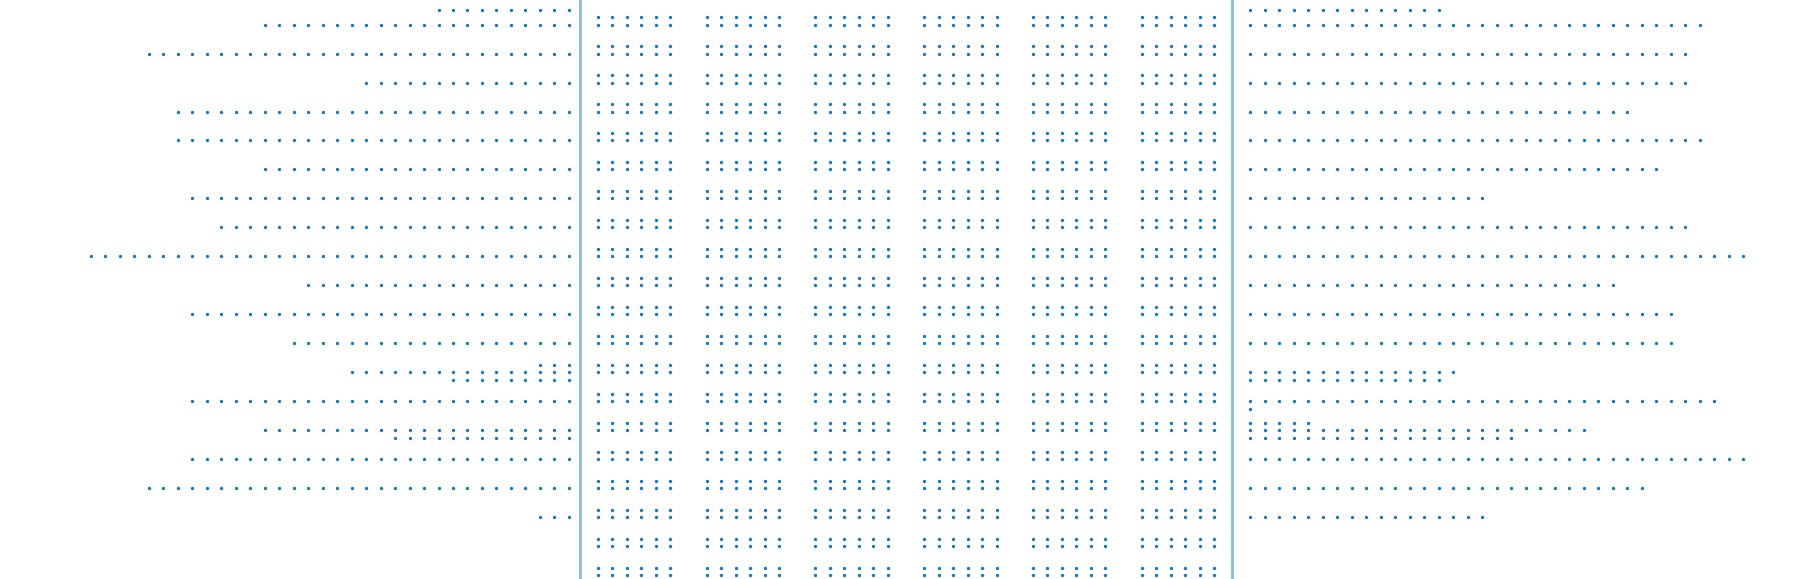


- FPGA Output (2453 atoms):



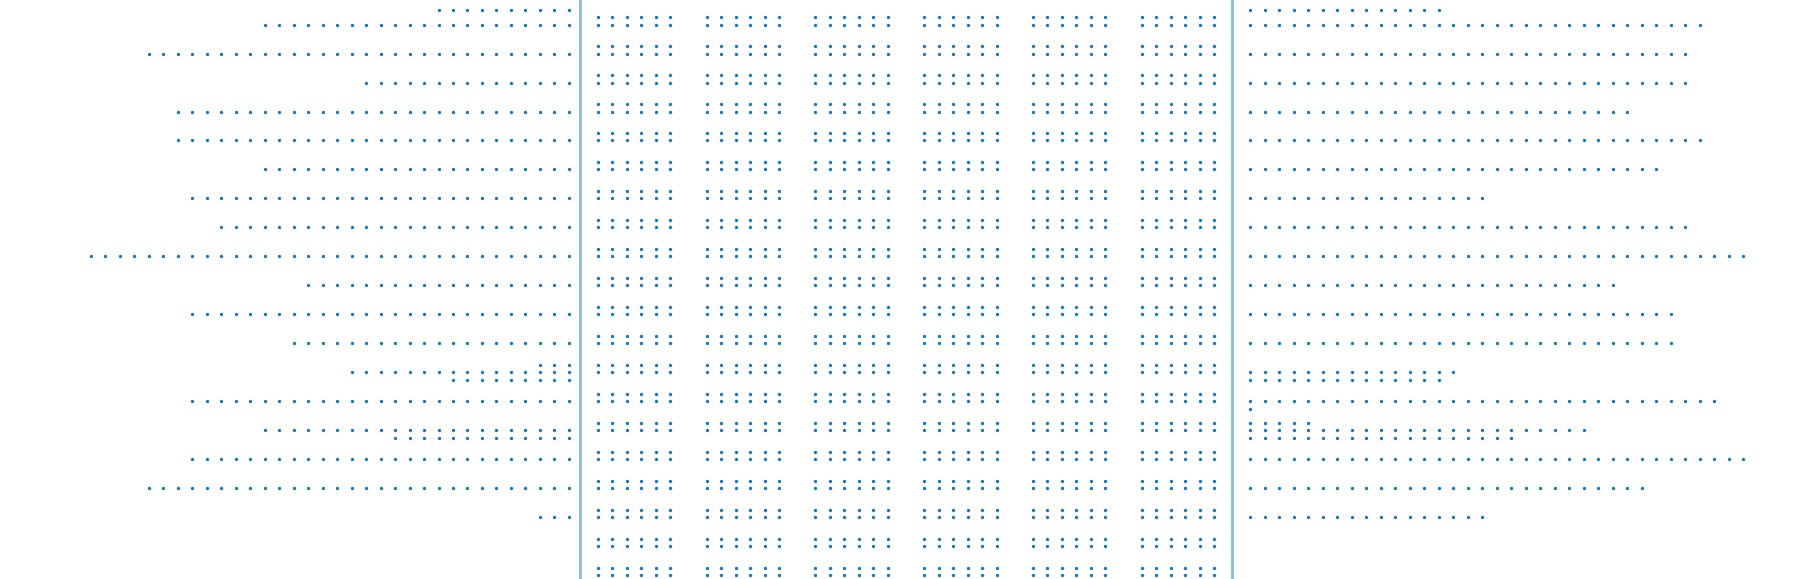


VALIDATION: MoveList Sorting Equivalence (Computation Zone)
FPGA atoms in zone   : 1440
Replay atoms in zone : 1440
✅ SUCCESS
The move list produced by the kernel is sufficient to realize
the same target configuration when applied by the sorting algorithm.

NOTE:
Differences outside the computation zone (parking regions) 
are not part of the algorithm’s correctness criteria.


In [100]:
#===============================================================================
# @brief Visualize sorted lattices and validate (canonical comparison)
#
# @details
#   1. Refresh FPGA output from memory
#   2. Save PNGs of reconstructed (from moves) and FPGA output
#   3. Display 3-way comparison: Initial → Reconstructed → FPGA
#   4. Validate equivalence ONLY inside computation zone
#
# @note
#   Parking regions are auxiliary and non-deterministic and are therefore
#   excluded from correctness validation.
#===============================================================================

print("\n" + "="*70)
print("VISUALIZE & VALIDATE RESULTS")
print("="*70 + "\n")

# Refresh FPGA output from memory
state_buf.invalidate()

# Save images (full lattice, for visualization only)
save_lattice_png(sorted_state, R0, R1, C0, C1, "lattice_sorted_from_moves.png")
save_lattice_png(state, R0, R1, C0, C1, "lattice_sorted_fpga.png")
print("✓ Saved lattice_sorted_from_moves.png")
print("✓ Saved lattice_sorted_fpga.png\n")

# Display 3-way comparison
print(f"- Initial ({np.sum(initial_state)} atoms):\n")
display(Image(filename="lattice_initial.png"))

print(f"\n- Reconstructed from Moves ({atoms_after} atoms):\n")
display(Image(filename="lattice_sorted_from_moves.png"))

print(f"\n- FPGA Output ({np.sum(state)} atoms):\n")
display(Image(filename="lattice_sorted_fpga.png"))

#===============================================================================
# Canonical validation: computation zone only
#===============================================================================

fpga_zone   = (state[R0:R1, C0:C1] != 0)
replay_zone = (sorted_state[R0:R1, C0:C1] != 0)

zone_match = np.array_equal(fpga_zone, replay_zone)

print("\n" + "="*70)
print("VALIDATION: MoveList Sorting Equivalence (Computation Zone)")
print("="*70)

print(f"FPGA atoms in zone   : {np.sum(fpga_zone)}")
print(f"Replay atoms in zone : {np.sum(replay_zone)}")

if zone_match:
    print("✅ SUCCESS")
    print("The move list produced by the kernel is sufficient to realize")
    print("the same target configuration when applied by the sorting algorithm.")
else:
    diff = np.sum(fpga_zone != replay_zone)
    print(f"❌ MISMATCH: {diff} differing cells in computation zone")

print("="*70)

print(
    "\nNOTE:\n"
    "Differences outside the computation zone (parking regions) \n"
    "are not part of the algorithm’s correctness criteria."
)
